In [1]:
!pip install pennylane scikit-learn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 47.8 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load only 2 classes
data = load_iris()
X = data.data[data.target != 2]
y = data.target[data.target != 2]

# Normalize and reduce to 2 features
X = StandardScaler().fit_transform(X)
X = PCA(n_components=2).fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


/usr/local/lib/python3.11/dist-packages/pennylane/capture/capture_operators.py:33: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.4.28. You have version 0.5.2 installed. Please downgrade JAX to <=0.4.28 to avoid runtime errors.
  warnings.warn(


In [3]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(weights, x=None):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    qml.CNOT(wires=[0, 1])
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)
    return qml.expval(qml.PauliZ(0))


In [4]:
def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

def square_loss(labels, predictions):
    loss = np.mean((labels - predictions) ** 2)
    return loss

def accuracy(labels, predictions):
    predictions = [1 if p >= 0 else 0 for p in predictions]
    acc = np.mean(np.array(predictions) == labels)
    return acc


In [5]:
weights = np.random.randn(n_qubits, requires_grad=True)
bias = np.array(0.0, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.4)
epochs = 20

for i in range(epochs):
    for x, y_label in zip(X_train, y_train):
        def cost(w, b): return square_loss(y_label, variational_classifier(w, b, x))
        weights, bias = opt.step(cost, weights, bias)

    predictions = [variational_classifier(weights, bias, x) for x in X_train]
    acc = accuracy(y_train, predictions)
    print(f"Epoch {i+1}: Accuracy = {acc:.3f}")


Epoch 1: Accuracy = 0.525
Epoch 2: Accuracy = 0.500
Epoch 3: Accuracy = 0.500
Epoch 4: Accuracy = 0.500
Epoch 5: Accuracy = 0.500
Epoch 6: Accuracy = 0.500
Epoch 7: Accuracy = 0.500
Epoch 8: Accuracy = 0.500
Epoch 9: Accuracy = 0.500
Epoch 10: Accuracy = 0.500
Epoch 11: Accuracy = 0.500
Epoch 12: Accuracy = 0.500
Epoch 13: Accuracy = 0.500
Epoch 14: Accuracy = 0.500
Epoch 15: Accuracy = 0.500
Epoch 16: Accuracy = 0.500
Epoch 17: Accuracy = 0.500
Epoch 18: Accuracy = 0.500
Epoch 19: Accuracy = 0.500
Epoch 20: Accuracy = 0.500


In [6]:
test_preds = [variational_classifier(weights, bias, x) for x in X_test]
test_acc = accuracy(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.3f}")


Test Accuracy: 0.450


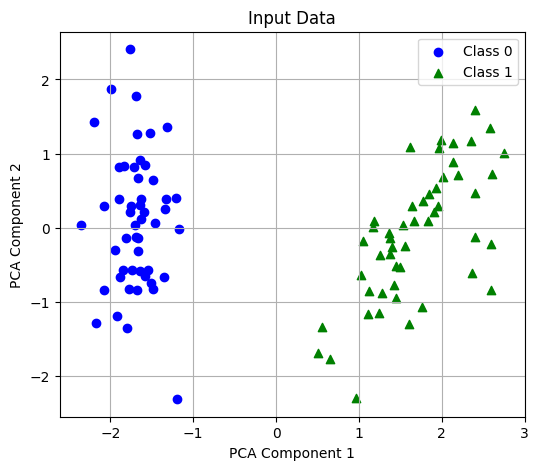

In [7]:
def plot_data(X, y, title="Input Data"):
    plt.figure(figsize=(6, 5))
    for label, marker, color in zip([0, 1], ['o', '^'], ['blue', 'green']):
        plt.scatter(X[y == label, 0], X[y == label, 1], marker=marker, color=color, label=f"Class {label}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_data(X, y)


In [8]:
train_acc_list = []


In [9]:
for i in range(epochs):
    for x, y_label in zip(X_train, y_train):
        def cost(w, b): return square_loss(y_label, variational_classifier(w, b, x))
        weights, bias = opt.step(cost, weights, bias)

    predictions = [variational_classifier(weights, bias, x) for x in X_train]
    acc = accuracy(y_train, predictions)
    train_acc_list.append(acc)
    print(f"Epoch {i+1}: Accuracy = {acc:.3f}")


Epoch 1: Accuracy = 0.500
Epoch 2: Accuracy = 0.500
Epoch 3: Accuracy = 0.500
Epoch 4: Accuracy = 0.500
Epoch 5: Accuracy = 0.500
Epoch 6: Accuracy = 0.500
Epoch 7: Accuracy = 0.500
Epoch 8: Accuracy = 0.500
Epoch 9: Accuracy = 0.500
Epoch 10: Accuracy = 0.500
Epoch 11: Accuracy = 0.500
Epoch 12: Accuracy = 0.500
Epoch 13: Accuracy = 0.500
Epoch 14: Accuracy = 0.500
Epoch 15: Accuracy = 0.500
Epoch 16: Accuracy = 0.500
Epoch 17: Accuracy = 0.500
Epoch 18: Accuracy = 0.500
Epoch 19: Accuracy = 0.500
Epoch 20: Accuracy = 0.500


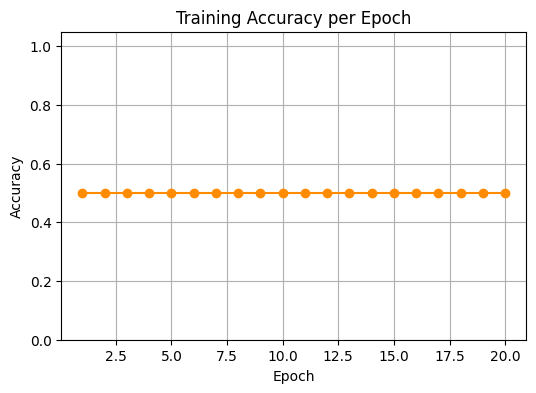

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_acc_list, marker='o', color='darkorange')
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()
